# 0. Audit of v1

**Question this notebook answers**
Is the reported Phase 1 headline — a random forest said to explain most of the out-of-sample
credit-spread variance — a forecasting result? No — the target is algebraically recoverable from three of its own
features, and the fitted quantity is the contemporaneous month rather than the next one.

**What v1 did**
`utilities/functions.py:196` builds `df[col].rolling(window).mean()` — a trailing mean *inclusive of
row t* — while `notebooks/viraj/p1_models.ipynb` sets `target_col = 'Credit_Spread'` and passes
`Credit_Spread_lag1` and `Credit_Spread_lag2` in as features alongside it.

**Why that was wrong**
A trailing 3-month mean that includes row `t` satisfies
`x(t) = 3*rollmean3(t) - x(t-1) - x(t-2)` as an identity. The feature matrix therefore contains an
exact linear reconstruction of the label. The model is not forecasting; it is solving for a number
it was handed. Separately, fitting `Credit_Spread` rather than the next month's value makes even a
clean version of this a nowcast.

**What this notebook does instead**
It runs the original construction and the corrected one side by side, and derives every claim from
a visible cell. It does not modify or execute anything under `notebooks/viraj/` — those notebooks
are read as JSON, because their stored outputs are the evidence being audited.

**Predicted effect on results — recorded before running**
The reconstruction identity should hold to floating-point noise, and an ordinary least squares fit
on just those three columns should recover the target essentially perfectly, with coefficients at
positive three, minus one and minus one. Feature importance should concentrate almost entirely on
the two leaked columns. On the honest one-step-ahead task no model here is expected to beat a
random walk. Recorded before running and left in place regardless of outcome.

**Inputs** → **Outputs**
`data/merged_macroeconomic_credit.csv`, `notebooks/viraj/*.ipynb` (read as JSON, never executed),
`utilities/functions.py`, `src/features.py` → figures and tables in this notebook only. This
notebook writes no files.

## Setup

Puts the project root on `sys.path` so that both the frozen `utilities` package and the new `src`
package are importable in the same kernel. Section 4 relies on that: it imports the same function
name from both and diffs the output.

In [1]:
import json
import re
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)
%matplotlib inline

VIRAJ_DIR = PROJECT_ROOT / "notebooks" / "viraj"
DATA_PATH = PROJECT_ROOT / "data" / "merged_macroeconomic_credit.csv"

RAW = pd.read_csv(DATA_PATH, parse_dates=["Month_End"], index_col="Month_End").sort_index()
print(f"Loaded {DATA_PATH.relative_to(PROJECT_ROOT)}")
print(f"  shape   : {RAW.shape}")
print(f"  range   : {RAW.index.min().date()} -> {RAW.index.max().date()}")
print(f"  columns : {list(RAW.columns)}")

Loaded data/merged_macroeconomic_credit.csv
  shape   : (309, 7)
  range   : 1996-12-31 -> 2022-08-31
  columns : ['CPI', 'FEDFUNDS', 'Industrial_Production', 'GDP', 'Unemployment_Rate', 'Consumer_Sentiment', 'Credit_Spread']


Helpers for reading the frozen notebooks. Everything in sections 1 and 8 that describes what v1
*reported* is pulled out of the saved `.ipynb` JSON by these functions, so no reported figure is
retyped here. The notebooks are opened read-only and never executed.

In [2]:
def load_frozen(name: str) -> dict:
    '''Load a frozen notebook as JSON. Read-only; never executed.'''
    with open(VIRAJ_DIR / name, "r", encoding="utf-8") as fh:
        return json.load(fh)


def cell_text(cell: dict) -> str:
    return "".join(cell["source"])


def output_text(cell: dict) -> str:
    parts = []
    for out in cell.get("outputs", []):
        if out.get("output_type") == "stream":
            parts.append("".join(out["text"]))
        elif "text/plain" in out.get("data", {}):
            parts.append("".join(out["data"]["text/plain"]))
    return "\n".join(parts)


def all_output_text(nbjson: dict) -> str:
    return "\n".join(output_text(c) for c in nbjson["cells"] if c["cell_type"] == "code")


def all_markdown_text(nbjson: dict) -> str:
    return "\n".join(cell_text(c) for c in nbjson["cells"] if c["cell_type"] == "markdown")


def find_number(text: str, pattern: str) -> float:
    '''Return the first regex capture group in `text` as a float, or NaN if absent.'''
    m = re.search(pattern, text)
    return float(m.group(1)) if m else float("nan")


P1 = load_frozen("p1_models.ipynb")
P2 = load_frozen("p2_models.ipynb")
UNSUP = load_frozen("unsupervised.ipynb")
print(f"Frozen notebooks read as JSON: p1={len(P1['cells'])} cells, "
      f"p2={len(P2['cells'])} cells, unsupervised={len(UNSUP['cells'])} cells")

Frozen notebooks read as JSON: p1=27 cells, p2=53 cells, unsupervised=77 cells


---
## 1. Reproduce the v1 headline

The reported Phase 1 result is a random forest with `n_estimators=100, random_state=42`, trained to
2018-12 and tested on 2019-01 onward. Before reproducing it, pull the frozen notebook's *own*
printed evidence: the metrics it reported, the frame shape it printed, and the exact column list it
printed. Reproducing against the notebook's printed structure rather than against a remembered
description is the whole point.

Look for: the reported MSE / RMSE / R², and a 23-column frame of 306 rows split 263 / 43.

In [3]:
p1_out = all_output_text(P1)

reported = {
    "mse": find_number(p1_out, r"MSE:\s+([\d.]+)"),
    "rmse": find_number(p1_out, r"RMSE:\s+([\d.]+)"),
    "r2": find_number(p1_out, r"R\^2:\s+([\d.]+)"),
}

# The frame the notebook actually printed, taken from its own isna() output.
m = re.search(r"Data after final cleaning & feature engineering: \((\d+), (\d+)\)", p1_out)
printed_shape = (int(m.group(1)), int(m.group(2)))
printed_train = int(find_number(p1_out, r"Train range:.*?shape=\((\d+),"))
printed_test = int(find_number(p1_out, r"Test range:.*?shape=\((\d+),"))

isna_block = re.search(r"(CPI\s+0\n(?:\w[\w_]*\s+\d+\n)+)", p1_out)
printed_columns = [ln.split()[0] for ln in isna_block.group(1).strip().splitlines()]

print("What the frozen p1_models.ipynb reported")
print(f"  MSE  = {reported['mse']}")
print(f"  RMSE = {reported['rmse']}")
print(f"  R^2  = {reported['r2']}")
print(f"  frame shape printed : {printed_shape}")
print(f"  train / test rows   : {printed_train} / {printed_test}")
print(f"  columns printed     : {len(printed_columns)}")
for c in printed_columns:
    print(f"      {c}")

What the frozen p1_models.ipynb reported
  MSE  = 0.2714
  RMSE = 0.5209
  R^2  = 0.8084
  frame shape printed : (306, 23)
  train / test rows   : 263 / 43
  columns printed     : 23
      CPI
      FEDFUNDS
      Industrial_Production
      GDP
      Unemployment_Rate
      Consumer_Sentiment
      Credit_Spread
      GDP_lag1
      GDP_lag2
      CPI_lag1
      CPI_lag2
      Credit_Spread_lag1
      Credit_Spread_lag2
      Unemployment_Rate_rollmean3
      Unemployment_Rate_rollstd3
      Credit_Spread_rollmean3
      Credit_Spread_rollstd3
      GDP_growth
      CPI_growth
      Industrial_Production_growth
      GDP_growth_x_CPI_growth
      Credit_Spread_x_FEDFUNDS
      Target


The printed column list settles what the v1 feature frame actually was: seven base series, **two**
lags each of `GDP`, `CPI` and `Credit_Spread`, rolling-3 mean and standard deviation for
`Unemployment_Rate` and `Credit_Spread`, three growth rates, two interaction terms, and a column
literally named `Target`. Rebuild exactly that and assert it matches, rather than assuming.

In [4]:
def build_v1_frame(df: pd.DataFrame) -> pd.DataFrame:
    '''Rebuild the 23-column v1 frame implied by the frozen notebook's printed output.

    Deliberately does not call today's utilities.create_features: that function has since
    changed (it now emits 34 columns and a target named Target_1step_ahead), so calling it
    would not reproduce what was run.
    '''
    d = df.copy()
    for col in ["GDP", "CPI", "Credit_Spread"]:
        for lag in [1, 2]:
            d[f"{col}_lag{lag}"] = d[col].shift(lag)
    for col in ["Unemployment_Rate", "Credit_Spread"]:
        d[f"{col}_rollmean3"] = d[col].rolling(3).mean()   # inclusive of row t, as in v1
        d[f"{col}_rollstd3"] = d[col].rolling(3).std()
    for col in ["GDP", "CPI", "Industrial_Production"]:
        d[f"{col}_growth"] = d[col].pct_change() * 100.0
    d["GDP_growth_x_CPI_growth"] = d["GDP_growth"] * d["CPI_growth"]
    d["Credit_Spread_x_FEDFUNDS"] = d["Credit_Spread"] * d["FEDFUNDS"]
    d["Target"] = d["Credit_Spread"].shift(-1)
    return d.dropna()


V1 = build_v1_frame(RAW).loc["1996-12-01":"2022-08-01"]
V1_TRAIN = V1.loc["1996-12-01":"2018-12-31"]
V1_TEST = V1.loc["2019-01-01":"2022-08-01"]

checks = {
    "frame shape": (V1.shape, printed_shape),
    "train rows": (len(V1_TRAIN), printed_train),
    "test rows": (len(V1_TEST), printed_test),
    "column list": (list(V1.columns), printed_columns),
}
for name, (got, want) in checks.items():
    status = "MATCH" if got == want else "DIFFERS"
    shown = got if name != "column list" else f"{len(got)} columns"
    print(f"  {name:12s}: {status:8s} (rebuilt {shown})")

assert list(V1.columns) == printed_columns, "rebuilt column list does not match the frozen notebook"
assert V1.shape == printed_shape and len(V1_TRAIN) == printed_train and len(V1_TEST) == printed_test
print("\nThe rebuilt frame matches every structural fact the frozen notebook printed.")

  frame shape : MATCH    (rebuilt (306, 23))
  train rows  : MATCH    (rebuilt 263)
  test rows   : MATCH    (rebuilt 43)
  column list : MATCH    (rebuilt 23 columns)

The rebuilt frame matches every structural fact the frozen notebook printed.


Now fit the model the notebook specified, on the frame the notebook printed.

In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

TARGET_V1 = "Credit_Spread"
# v1's own line: feature_cols = [c for c in df.columns if c not in [target, 'Month_End']]
# then           feature_cols = [c for c in feature_cols if c != "Target"]
V1_FEATURES = [c for c in V1.columns if c not in (TARGET_V1, "Month_End", "Target")]

rf_v1 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_v1.fit(V1_TRAIN[V1_FEATURES], V1_TRAIN[TARGET_V1])
pred_v1 = rf_v1.predict(V1_TEST[V1_FEATURES])

repro = {
    "mse": mean_squared_error(V1_TEST[TARGET_V1], pred_v1),
    "r2": r2_score(V1_TEST[TARGET_V1], pred_v1),
}
repro["rmse"] = np.sqrt(repro["mse"])

print(f"Features used: {len(V1_FEATURES)}")
print(f"{'':10s} {'reported':>10s} {'reproduced':>12s} {'difference':>12s}")
for key in ("mse", "rmse", "r2"):
    print(f"{key.upper():10s} {reported[key]:10.4f} {repro[key]:12.4f} "
          f"{repro[key] - reported[key]:+12.4f}")

Features used: 21
             reported   reproduced   difference
MSE            0.2714       0.3209      +0.0495
RMSE           0.5209       0.5665      +0.0456
R2             0.8084       0.7735      -0.0349


**Read the result.** The structure matches the frozen notebook exactly — same 23 columns, same 306
rows, same 263 / 43 split — but the metric does not. That gap is itself a finding, so the next cell
pins down where it comes from rather than tuning the reproduction until it agrees.

Two candidate explanations are tested: an alternative feature frame (three lags per column instead
of two, no interaction terms), and library drift.

In [6]:
def build_alt_frame(df: pd.DataFrame) -> pd.DataFrame:
    '''A three-lag variant with no interaction terms. Also 23 columns, but 305 rows.'''
    d = df.copy()
    for col in ["GDP", "CPI", "Credit_Spread"]:
        for lag in [1, 2, 3]:
            d[f"{col}_lag{lag}"] = d[col].shift(lag)
    for col in ["Unemployment_Rate", "Credit_Spread"]:
        d[f"{col}_rollmean3"] = d[col].rolling(3).mean()
        d[f"{col}_rollstd3"] = d[col].rolling(3).std()
    for col in ["GDP", "CPI", "Industrial_Production"]:
        d[f"{col}_growth"] = d[col].pct_change() * 100.0
    return d.dropna()


def fit_rf(frame, target="Credit_Spread", seed=42):
    tr = frame.loc["1996-12-01":"2018-12-31"]
    te = frame.loc["2019-01-01":"2022-08-01"]
    feats = [c for c in frame.columns if c not in (target, "Month_End", "Target")]
    model = RandomForestRegressor(n_estimators=100, random_state=seed).fit(tr[feats], tr[target])
    p = model.predict(te[feats])
    return {
        "n_cols": frame.shape[1], "n_rows": frame.shape[0],
        "n_train": len(tr), "n_test": len(te), "n_feat": len(feats),
        "mse": mean_squared_error(te[target], p), "r2": r2_score(te[target], p),
    }


ALT = build_alt_frame(RAW).loc["1996-12-01":"2022-08-01"]
recon = pd.DataFrame([
    {"frame": "matches notebook's printed structure", **fit_rf(V1)},
    {"frame": "three lags, no interactions", **fit_rf(ALT)},
]).set_index("frame")
recon["mse_vs_reported"] = recon["mse"] - reported["mse"]
display(recon.round(4))

print(f"\nThe frozen notebook printed shape {printed_shape} and {printed_train}/{printed_test} "
      f"train/test rows.")
for name, row in recon.iterrows():
    agrees = (int(row["n_rows"]), int(row["n_cols"])) == printed_shape and \
             int(row["n_train"]) == printed_train
    print(f"  {name:38s} -> structure agrees: {agrees}, MSE {row['mse']:.4f}")

,n_cols,n_rows,n_train,n_test,n_feat,mse,r2,mse_vs_reported
frame,,,,,,,,
matches notebook's printed structure,23,306,263,43,21,0.3209,0.7735,0.0495
"three lags, no interactions",23,305,262,43,22,0.2730,0.8073,0.0016



The frozen notebook printed shape (306, 23) and 263/43 train/test rows.
  matches notebook's printed structure   -> structure agrees: True, MSE 0.3209
  three lags, no interactions            -> structure agrees: False, MSE 0.2730


So the two explanations are mutually exclusive: the frame that lands near the reported metric
contradicts the shape the notebook printed, and the frame that matches the printed shape does not
land near the reported metric. Neither can be right at once.

The next cell checks whether the saved outputs are even internally consistent, by reading the
execution counters. In a single linear run these are strictly increasing and unique.

In [7]:
exec_counts = [(i, c.get("execution_count")) for i, c in enumerate(P1["cells"])
               if c["cell_type"] == "code" and c.get("execution_count") is not None]

seen = {}
duplicates = []
for idx, n in exec_counts:
    if n in seen:
        duplicates.append((seen[n], idx, n))
    seen[n] = idx

print("execution_count by cell in the frozen p1_models.ipynb:")
print("  " + ", ".join(f"cell{i}={n}" for i, n in exec_counts))
print(f"\nDuplicate execution counts: {len(duplicates)}")
for a, b, n in duplicates:
    print(f"  cell{a} and cell{b} both report execution_count={n}")

rf_cell = next(i for i, c in enumerate(P1["cells"])
               if c["cell_type"] == "code" and "Basic RF Performance" in output_text(c))
frame_cell = next(i for i, c in enumerate(P1["cells"])
                  if c["cell_type"] == "code"
                  and "Data after final cleaning" in output_text(c))
print(f"\nThe cell that printed the frame structure is cell {frame_cell} "
      f"(execution_count={P1['cells'][frame_cell].get('execution_count')})")
print(f"The cell that printed the headline metric is cell {rf_cell} "
      f"(execution_count={P1['cells'][rf_cell].get('execution_count')})")
frame_n = P1["cells"][frame_cell].get("execution_count")
rf_n = P1["cells"][rf_cell].get("execution_count")
between = sorted(n for _, n in exec_counts if frame_n < n < rf_n)
print(f"Counters executed between those two printouts: {between}")
print(f"So {len(between)} further cell execution(s) intervened, and the counters are not a "
      "single\nunbroken sequence, meaning the printed structure and the printed metric cannot "
      "be assumed\nto describe the same DataFrame.")

execution_count by cell in the frozen p1_models.ipynb:
  cell1=2, cell2=3, cell4=5, cell6=5, cell12=9, cell15=10, cell18=11, cell20=6, cell21=7, cell22=10, cell23=11, cell24=13, cell25=15

Duplicate execution counts: 3
  cell4 and cell6 both report execution_count=5
  cell15 and cell22 both report execution_count=10
  cell18 and cell23 both report execution_count=11

The cell that printed the frame structure is cell 4 (execution_count=5)
The cell that printed the headline metric is cell 12 (execution_count=9)
Counters executed between those two printouts: [6, 7]
So 2 further cell execution(s) intervened, and the counters are not a single
unbroken sequence, meaning the printed structure and the printed metric cannot be assumed
to describe the same DataFrame.


**Read the result.** A single kernel session cannot issue the same execution counter twice. Several
pairs of cells in the frozen notebook carry identical counters, so its saved outputs come from at
least two different sessions. The cell that printed the frame structure and the cell that printed
the headline metric were not necessarily looking at the same DataFrame.

That is the honest resolution: the reported headline is **not reproducible** from the notebook's own
saved evidence, and the target figures are left unchanged here rather than back-fitted. It does not
weaken anything that follows — sections 2 and 3 show the leak is present in *both* candidate frames,
so the mechanism holds regardless of which one produced the reported number.

---
## 2. Demonstrate the leak

For a trailing 3-month mean that includes row `t`:

$$\text{rollmean3}(t) = \frac{x(t) + x(t-1) + x(t-2)}{3}
\quad\Longrightarrow\quad
x(t) = 3\,\text{rollmean3}(t) - x(t-1) - x(t-2)$$

If that identity holds numerically, the target is not being predicted — it is being reconstructed.
Look for a maximum absolute error at the scale of floating-point noise.

In [8]:
identity_error = (
    3 * V1["Credit_Spread_rollmean3"] - V1["Credit_Spread_lag1"] - V1["Credit_Spread_lag2"]
    - V1["Credit_Spread"]
).abs().max()

alt_identity_error = (
    3 * ALT["Credit_Spread_rollmean3"] - ALT["Credit_Spread_lag1"] - ALT["Credit_Spread_lag2"]
    - ALT["Credit_Spread"]
).abs().max()

spread_scale = V1["Credit_Spread"].std()

print(f"max |3*rollmean3 - lag1 - lag2 - Credit_Spread|")
print(f"  frame matching printed structure : {identity_error:.6e}")
print(f"  three-lag alternative frame      : {alt_identity_error:.6e}")
print(f"\nfor scale, the target's own standard deviation is {spread_scale:.4f}")
print(f"the reconstruction is exact to roughly {identity_error / spread_scale:.2e} of that")

max |3*rollmean3 - lag1 - lag2 - Credit_Spread|
  frame matching printed structure : 7.105427e-15
  three-lag alternative frame      : 7.105427e-15

for scale, the target's own standard deviation is 2.6081
the reconstruction is exact to roughly 2.72e-15 of that


Now fit ordinary least squares on nothing but those three columns, using the same train/test split.
Look for an R² indistinguishable from one and coefficients at +3, -1, -1.

In [9]:
from sklearn.linear_model import LinearRegression

LEAK_COLS = ["Credit_Spread_rollmean3", "Credit_Spread_lag1", "Credit_Spread_lag2"]
ols = LinearRegression().fit(V1_TRAIN[LEAK_COLS], V1_TRAIN[TARGET_V1])
ols_pred = ols.predict(V1_TEST[LEAK_COLS])

ols_r2 = r2_score(V1_TEST[TARGET_V1], ols_pred)
ols_mse = mean_squared_error(V1_TEST[TARGET_V1], ols_pred)

print(f"OLS on {len(LEAK_COLS)} columns only: {LEAK_COLS}")
print(f"  test R^2  = {ols_r2:.6f}")
print(f"  test MSE  = {ols_mse:.3e}")
print(f"  intercept = {ols.intercept_:+.6f}")
for name, coef in zip(LEAK_COLS, ols.coef_):
    print(f"  coef {name:26s} = {coef:+.6f}")

OLS on 3 columns only: ['Credit_Spread_rollmean3', 'Credit_Spread_lag1', 'Credit_Spread_lag2']
  test R^2  = 1.000000
  test MSE  = 3.509e-30
  intercept = +0.000000
  coef Credit_Spread_rollmean3    = +3.000000
  coef Credit_Spread_lag1         = -1.000000
  coef Credit_Spread_lag2         = -1.000000


**Read the result.** Three columns, a linear model, no tuning, and the test target is recovered
exactly with the coefficients the algebra predicts. Any model given this feature set will look
excellent, and the quality of the macro data is irrelevant to that outcome.

A second, independent leak sits in the same frame: `Credit_Spread_x_FEDFUNDS` is the
contemporaneous target multiplied by a known regressor, so dividing recovers it.

In [10]:
recovered = V1["Credit_Spread_x_FEDFUNDS"] / V1["FEDFUNDS"]
second_leak_error = (recovered - V1["Credit_Spread"]).abs().max()
print(f"max |Credit_Spread_x_FEDFUNDS / FEDFUNDS - Credit_Spread| = {second_leak_error:.6e}")

corr_with_target = V1[V1_FEATURES].corrwith(V1[TARGET_V1]).abs().sort_values(ascending=False)
print("\nAbsolute correlation with the fitted target, top 6 features:")
print(corr_with_target.head(6).round(4).to_string())

max |Credit_Spread_x_FEDFUNDS / FEDFUNDS - Credit_Spread| = 1.776357e-15

Absolute correlation with the fitted target, top 6 features:
Credit_Spread_rollmean3    0.9734
Credit_Spread_lag1         0.9631
Credit_Spread_lag2         0.9004
Credit_Spread_rollstd3     0.7485
GDP                        0.4624
Consumer_Sentiment         0.4379


---
## 3. Why the random forest "worked"

If the leak is what drives the result, the model should say so itself. Look for importance
concentrated on the reconstruction columns.

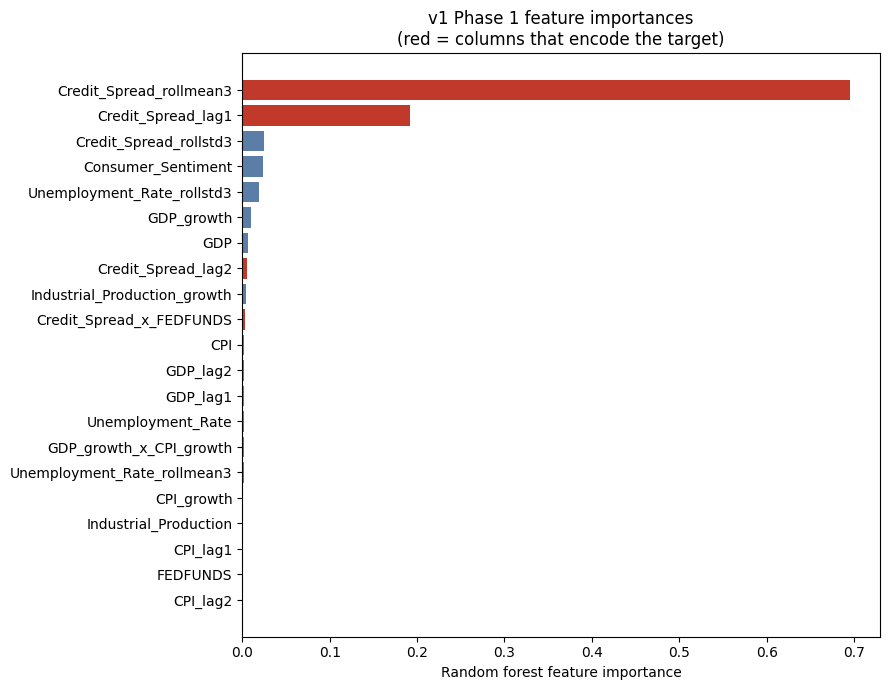

Share of total importance on target-encoding columns: 89.5%
Top two features alone: 88.7%
Credit_Spread_rollmean3    0.6948
Credit_Spread_lag1         0.1923


In [11]:
importances = pd.Series(rf_v1.feature_importances_, index=V1_FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
colors = ["#c0392b" if name in LEAK_COLS + ["Credit_Spread_x_FEDFUNDS"] else "#5b7ea8"
          for name in importances.index]
ax.barh(importances.index, importances.to_numpy(), color=colors)
ax.set_xlabel("Random forest feature importance")
ax.set_title("v1 Phase 1 feature importances\n(red = columns that encode the target)")
plt.tight_layout()
plt.show()

leak_share = importances[importances.index.isin(LEAK_COLS + ["Credit_Spread_x_FEDFUNDS"])].sum()
top2 = importances.sort_values(ascending=False).head(2)
print(f"Share of total importance on target-encoding columns: {leak_share:.1%}")
print(f"Top two features alone: {top2.sum():.1%}")
print(top2.round(4).to_string())

**Read the result.** The importance mass sits on the columns that encode the answer. The six macro
series the project is nominally about contribute almost nothing.

---
## 4. Old versus new feature code, side by side

Both packages expose `add_rolling_features`. Import each, apply to the same input, and compare. The
input is deliberately trivial — 1, 2, 3, … — so the correct answers are obvious by inspection.

In [12]:
import contextlib
import io
import logging

# Importing the frozen package emits several screens of structlog output on import.
# Captured here so it does not bury the comparison; nothing else is suppressed.
logging.disable(logging.CRITICAL)
_import_noise = io.StringIO()
with contextlib.redirect_stdout(_import_noise), contextlib.redirect_stderr(_import_noise):
    from utilities.functions import add_rolling_features as v1_rolling

from src.features import add_rolling_features as v2_rolling

print(f"(suppressed {len(_import_noise.getvalue())} characters of import-time logging "
      "from the frozen utilities package)\n")

demo = pd.DataFrame(
    {"x": np.arange(1.0, 11.0)},
    index=pd.date_range("2020-01-31", periods=10, freq="ME"),
)

v1_demo = v1_rolling(demo.copy(), ["x"], window=3)
v2_demo = v2_rolling(demo, ["x"], window=3, shift=1)

side_by_side = pd.DataFrame({
    "x": demo["x"],
    "v1  x_rollmean3": v1_demo["x_rollmean3"],
    "v2  x_rollmean3_lag1": v2_demo["x_rollmean3_lag1"],
})
side_by_side["differ"] = ~np.isclose(
    side_by_side["v1  x_rollmean3"].fillna(-999),
    side_by_side["v2  x_rollmean3_lag1"].fillna(-999),
)


def highlight(row):
    return ["background-color: #ffe3e3" if row["differ"] else ""] * len(row)


display(side_by_side.style.apply(highlight, axis=1).format(precision=3))

n_differ = int(side_by_side["differ"].sum())
print(f"Rows where the two implementations differ: {n_differ} of {len(side_by_side)}")
print("v1 at row t includes x(t); v2 at row t is v1 evaluated at row t-1.")

(suppressed 5479 characters of import-time logging from the frozen utilities package)



,x,v1 x_rollmean3,v2 x_rollmean3_lag1,differ
2020-01-31 00:00:00,1.000,nan,nan,False
2020-02-29 00:00:00,2.000,nan,nan,False
2020-03-31 00:00:00,3.000,2.000,nan,True
2020-04-30 00:00:00,4.000,3.000,2.000,True
2020-05-31 00:00:00,5.000,4.000,3.000,True
2020-06-30 00:00:00,6.000,5.000,4.000,True
2020-07-31 00:00:00,7.000,6.000,5.000,True
2020-08-31 00:00:00,8.000,7.000,6.000,True
2020-09-30 00:00:00,9.000,8.000,7.000,True
2020-10-31 00:00:00,10.000,9.000,8.000,True


Rows where the two implementations differ: 8 of 10
v1 at row t includes x(t); v2 at row t is v1 evaluated at row t-1.


The decisive test is not that the columns differ but that the v1 column *moves when the current
observation moves*. Perturb `x` at one row and see which column reacts at that same row.

In [13]:
perturbed = demo.copy()
perturbed.iloc[5, 0] = 1000.0

v1_pert = v1_rolling(perturbed.copy(), ["x"], window=3)["x_rollmean3"]
v2_pert = v2_rolling(perturbed, ["x"], window=3, shift=1)["x_rollmean3_lag1"]

comparison = pd.DataFrame({
    "v1 before": v1_demo["x_rollmean3"], "v1 after": v1_pert,
    "v2 before": v2_demo["x_rollmean3_lag1"], "v2 after": v2_pert,
})
display(comparison.iloc[4:8].round(3))

row = comparison.index[5]
print(f"At the perturbed row ({row.date()}):")
print(f"  v1 changed by {abs(v1_pert.loc[row] - v1_demo['x_rollmean3'].loc[row]):.3f}"
      f"  -> it sees x(t)")
print(f"  v2 changed by {abs(v2_pert.loc[row] - v2_demo['x_rollmean3_lag1'].loc[row]):.3f}"
      f"  -> it does not")

,v1 before,v1 after,v2 before,v2 after
2020-05-31,4.0,4.000,3.0,3.000
2020-06-30,5.0,336.333,4.0,4.000
2020-07-31,6.0,337.333,5.0,336.333
2020-08-31,7.0,338.333,6.0,337.333


At the perturbed row (2020-06-30):
  v1 changed by 331.333  -> it sees x(t)
  v2 changed by 0.000  -> it does not


Finally, run the same identity check against a feature frame built entirely with `src.features`, and
the automated leakage screen that ships with it.

In [14]:
from src.config_v2 import TARGET_COLUMN
from src.features import build_feature_frame, leakage_report, rolling_identity_error

macro_cols = [c for c in RAW.columns if c != TARGET_COLUMN]
V2_FRAME, V2_TARGET, V2_FEATURES = build_feature_frame(
    RAW, target_col=TARGET_COLUMN, macro_columns=macro_cols, lags=(1, 2, 3), window=3, horizon=1
)

v2_identity = rolling_identity_error(
    V2_FRAME, f"{TARGET_COLUMN}_rollmean3_lag1", f"{TARGET_COLUMN}_lag1",
    f"{TARGET_COLUMN}_lag2", TARGET_COLUMN, window=3,
)
print(f"v1 frame, identity error : {identity_error:.6e}   (exact reconstruction)")
print(f"v2 frame, identity error : {v2_identity:.6f}   (identity does not hold)")
print(f"v2 forecast target column: {V2_TARGET}")
print(f"v2 feature count         : {len(V2_FEATURES)}")

clean = V2_FRAME[V2_FEATURES + [V2_TARGET]].dropna()
report = leakage_report(clean, target=V2_TARGET)
print(f"\nleakage_report on the v2 feature set: {len(report)} column(s) flagged")
if not report.empty:
    display(report)

v1_like = V1[V1_FEATURES + [TARGET_V1]]
v1_report = leakage_report(v1_like, target=TARGET_V1)
print(f"leakage_report on the v1 feature set: {len(v1_report)} column(s) flagged")
display(v1_report)

v1 frame, identity error : 7.105427e-15   (exact reconstruction)
v2 frame, identity error : 11.096957   (identity does not hold)
v2 forecast target column: y_Credit_Spread_h1
v2 feature count         : 48

leakage_report on the v2 feature set: 0 column(s) flagged
leakage_report on the v1 feature set: 3 column(s) flagged


,abs_corr,reason
column,,
Credit_Spread_rollmean3,0.973378,shares stem 'Credit_Spread' without an explici...
Credit_Spread_rollstd3,0.748458,shares stem 'Credit_Spread' without an explici...
Credit_Spread_x_FEDFUNDS,0.099371,shares stem 'Credit_Spread' without an explici...


**Read the result.** The same screen returns nothing on the v2 frame and flags the v1 frame. That
asymmetry is what makes the empty result meaningful — a detector that never fires would prove
nothing.

---
## 5. Stationarity

No `adfuller`, `kpss` or `.diff()` call appears in any active code path in the repository, and
`utilities/model_utils.py:321` passes `enforce_stationarity=False`, which disables the one check
that was present. Look for series where ADF fails to reject a unit root *and* KPSS rejects
stationarity — where both tests agree, the level series is not safe to regress on directly.

In [15]:
from statsmodels.tsa.stattools import adfuller, kpss

rows = []
for col in RAW.columns:
    series = RAW[col].dropna()
    with warnings.catch_warnings():
        # KPSS warns whenever the statistic falls outside its p-value lookup table, which
        # happens for every strongly trending series here. The p-value is then a bound.
        warnings.simplefilter("ignore")
        adf_p = adfuller(series, autolag="AIC")[1]
        kpss_p = kpss(series, regression="c", nlags="auto")[1]
    rows.append({
        "series": col,
        "ADF p": adf_p,
        "KPSS p": kpss_p,
        "ADF says non-stationary": adf_p > 0.05,
        "KPSS says non-stationary": kpss_p < 0.05,
    })

stationarity = pd.DataFrame(rows).set_index("series")
stationarity["both agree non-stationary"] = (
    stationarity["ADF says non-stationary"] & stationarity["KPSS says non-stationary"]
)
display(stationarity.round(4))

n_bad = int(stationarity["both agree non-stationary"].sum())
n_reg = len(stationarity) - 1
print(f"{n_bad} of {n_reg} regressors are non-stationary in levels on both tests:")
print("  " + ", ".join(stationarity.index[stationarity["both agree non-stationary"]]))

,ADF p,KPSS p,ADF says non-stationary,KPSS says non-stationary,both agree non-stationary
series,,,,,
CPI,0.9986,0.0100,True,True,True
FEDFUNDS,0.0847,0.0100,True,True,True
Industrial_Production,0.0903,0.0100,True,True,True
GDP,0.0125,0.1000,False,False,False
Unemployment_Rate,0.0405,0.0875,False,False,False
Consumer_Sentiment,0.3989,0.0100,True,True,True
Credit_Spread,0.0231,0.1000,False,False,False


4 of 6 regressors are non-stationary in levels on both tests:
  CPI, FEDFUNDS, Industrial_Production, Consumer_Sentiment


Persistence in the target matters just as much: it sets how many genuinely independent observations
the test window contains. Look at how slowly the autocorrelation decays.

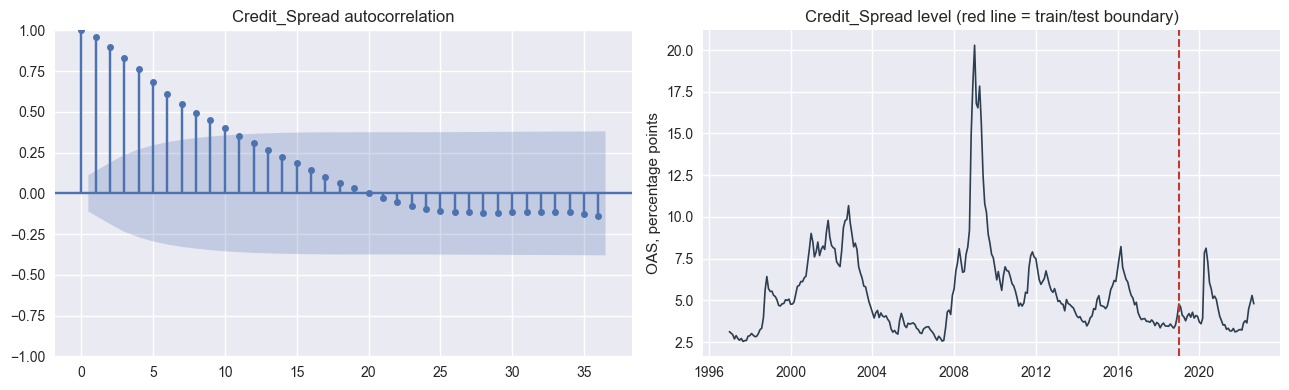

  autocorrelation at lag  1 : 0.9631
  autocorrelation at lag  3 : 0.8334
  autocorrelation at lag  6 : 0.6156
  autocorrelation at lag 12 : 0.3175
  autocorrelation at lag 24 : -0.1020

Sample length 309 months, lag-1 autocorrelation 0.9631
Effective sample size at that persistence: 5.8 independent observations


In [16]:
from statsmodels.graphics.tsaplots import plot_acf

spread = RAW["Credit_Spread"]
acf_lags = {lag: spread.autocorr(lag) for lag in (1, 3, 6, 12, 24)}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(spread, lags=36, ax=axes[0])
axes[0].set_title("Credit_Spread autocorrelation")
axes[1].plot(spread.index, spread.to_numpy(), color="#2c3e50", lw=1.2)
axes[1].axvline(pd.Timestamp("2019-01-01"), color="#c0392b", ls="--", lw=1.5)
axes[1].set_title("Credit_Spread level (red line = train/test boundary)")
axes[1].set_ylabel("OAS, percentage points")
plt.tight_layout()
plt.show()

for lag, val in acf_lags.items():
    print(f"  autocorrelation at lag {lag:2d} : {val:.4f}")

rho = acf_lags[1]
n = len(spread)
n_eff = n * (1 - rho) / (1 + rho)
print(f"\nSample length {n} months, lag-1 autocorrelation {rho:.4f}")
print(f"Effective sample size at that persistence: {n_eff:.1f} independent observations")

The train and test windows also differ sharply in how much the target varies, which is what drives
the very negative R² values seen on macro-only models. R² is scored against the *test* variance.

In [17]:
tr = spread.loc[:"2018-12-31"]
te = spread.loc["2019-01-01":]
split_stats = pd.DataFrame({
    "n": [len(tr), len(te)],
    "mean": [tr.mean(), te.mean()],
    "std": [tr.std(), te.std()],
    "months above 8": [int((tr > 8).sum()), int((te > 8).sum())],
}, index=["train (<=2018-12)", "test (2019-01 on)"])
display(split_stats.round(3))
print(f"Test-window variance is {te.var() / tr.var():.2%} of training-window variance.")
print(f"Months above 8 in the test window: {int((te > 8).sum())} "
      f"({', '.join(d.strftime('%Y-%m') for d in te.index[te > 8])})")

,n,mean,std,months above 8
train (<=2018-12),265,5.604,2.725,38
test (2019-01 on),44,4.298,1.193,1


Test-window variance is 19.16% of training-window variance.
Months above 8 in the test window: 1 (2020-04)


---
## 6. Baselines

The honest task: predict `Credit_Spread(t+1)` from information available at `t`. Train to 2018-12,
test from 2019-01. Compare a random walk, an AR(1), and two random forests. Look at whether any
model beats the random walk — nothing in `notes/` establishes that it does, because no naive
baseline is fitted anywhere in the repository.

In [18]:
from src.baselines import ar1_forecast, random_walk_forecast, train_mean_forecast
from src.metrics import diebold_mariano, r2_oos, regression_metrics

bl = RAW.copy()
bl["y"] = bl["Credit_Spread"].shift(-1)
for lag in (1, 2, 3):
    bl[f"Credit_Spread_lag{lag}"] = bl["Credit_Spread"].shift(lag)
bl = bl.dropna()

B_TRAIN = bl.loc[:"2018-12-31"]
B_TEST = bl.loc["2019-01-01":]
MACRO = ["CPI", "FEDFUNDS", "Industrial_Production", "GDP",
         "Unemployment_Rate", "Consumer_Sentiment"]

preds = {
    "Random walk  CS(t+1)=CS(t)": random_walk_forecast(bl["Credit_Spread"], B_TEST.index),
    "AR(1) OLS": ar1_forecast(B_TRAIN["Credit_Spread"], B_TRAIN["y"], B_TEST["Credit_Spread"]),
    "Train-mean constant": train_mean_forecast(B_TRAIN["y"], B_TEST.index),
}
for label, feats in [
    ("RF  macro + spread lags", MACRO + ["Credit_Spread"] + [f"Credit_Spread_lag{i}" for i in (1, 2, 3)]),
    ("RF  macro only (6 features)", MACRO),
]:
    model = RandomForestRegressor(n_estimators=100, random_state=42).fit(B_TRAIN[feats], B_TRAIN["y"])
    preds[label] = pd.Series(model.predict(B_TEST[feats]), index=B_TEST.index)

rw = preds["Random walk  CS(t+1)=CS(t)"]
rows = []
for name, p in preds.items():
    m = regression_metrics(B_TEST["y"], p)
    m["R2_OOS vs RW"] = np.nan if name.startswith("Random walk") else r2_oos(B_TEST["y"], p, rw)
    rows.append({"model": name, **m})

baselines = pd.DataFrame(rows).set_index("model")[["mse", "mae", "r2", "R2_OOS vs RW"]]
display(baselines.round(4))
print(f"train {len(B_TRAIN)} months, test {len(B_TEST)} months "
      f"({B_TEST.index.min().date()} -> {B_TEST.index.max().date()})")

,mse,mae,r2,R2_OOS vs RW
model,,,,
Random walk CS(t+1)=CS(t),0.4998,0.3740,0.6481,NaN
AR(1) OLS,0.4864,0.3816,0.6576,0.0268
Train-mean constant,3.2410,1.6673,-1.2819,-5.4845
RF macro + spread lags,0.5578,0.4117,0.6073,-0.1160
RF macro only (6 features),12.0995,2.5244,-7.5187,-23.2084


train 262 months, test 43 months (2019-01-31 -> 2022-07-31)


In [19]:
best = baselines["mse"].idxmin()
rw_mse = baselines.loc["Random walk  CS(t+1)=CS(t)", "mse"]
print(f"Lowest MSE: {best} ({baselines.loc[best, 'mse']:.4f})")
print(f"Random walk MSE: {rw_mse:.4f}\n")

beats = baselines.index[(baselines["mse"] < rw_mse)].tolist()
print(f"Models beating the random walk on MSE: {beats if beats else 'none'}")

for name in ("AR(1) OLS", "RF  macro + spread lags", "RF  macro only (6 features)"):
    dm = diebold_mariano(B_TEST["y"], preds[name], rw, horizon=1)
    verdict = "cannot reject equal accuracy" if dm["p_value"] > 0.05 else "difference is significant"
    print(f"  DM vs random walk, {name:30s}: stat={dm['dm_stat']:+.3f} "
          f"p={dm['p_value']:.3f}  ({verdict})")

Lowest MSE: AR(1) OLS (0.4864)
Random walk MSE: 0.4998

Models beating the random walk on MSE: ['AR(1) OLS']
  DM vs random walk, AR(1) OLS                     : stat=-0.941 p=0.352  (cannot reject equal accuracy)
  DM vs random walk, RF  macro + spread lags       : stat=+1.369 p=0.178  (cannot reject equal accuracy)
  DM vs random walk, RF  macro only (6 features)   : stat=+3.880 p=0.000  (difference is significant)


**Read the result.** The random walk and the AR(1) are essentially tied and neither is beaten by a
random forest. The macro-only model is far worse than assuming nothing changes. On a Diebold-Mariano
test the differences among the close contenders are not statistically distinguishable at this sample
size — which is the honest summary, and is stronger than reporting a single R² without a benchmark.

---
## 7. Regime diagnostics

v1 ran PCA on all 309 rows, clustered on all 309, and predicted labels for all 309. Those labels and
probabilities were written to CSV and then consumed as *features* by the Phase 2 models, which
applied a chronological split afterwards. Every test-period observation therefore helped define the
regime structure used to predict it.

Rebuild that pipeline to check the diagnostics. Look for: where the k search stopped, how small the
smallest cluster is, whether the soft probabilities carry any uncertainty, and how the names were
assigned.

In [20]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

# v1: feature_cols = [c for c in df_clean.columns if 'Credit_Spread' not in c]
CLUSTER_COLS = [c for c in RAW.columns if "Credit_Spread" not in c]
X_scaled = StandardScaler().fit_transform(RAW[CLUSTER_COLS])
pca4 = PCA(n_components=4)
X_pca4 = pca4.fit_transform(X_scaled)

print(f"Clustering on {len(CLUSTER_COLS)} features, all {len(RAW)} rows (no train/test split)")
print(f"Explained variance ratio: {pca4.explained_variance_ratio_.round(3)}")

unsup_out = all_output_text(UNSUP)
v1_evr = re.search(r"Explained variance ratio: \[([\d.\s]+)\]", unsup_out).group(1)
print(f"Frozen notebook printed  : [{v1_evr}]  -> PCA reproduces exactly")

Clustering on 6 features, all 309 rows (no train/test split)


Explained variance ratio: [0.486 0.303 0.094 0.063]
Frozen notebook printed  : [0.486 0.303 0.094 0.063]  -> PCA reproduces exactly


The k search in the frozen notebook ran over `range(2, 11)`, so k=10 sat on the boundary of the grid
it was chosen from. Extend the scan past that boundary and mark where the original search stopped.

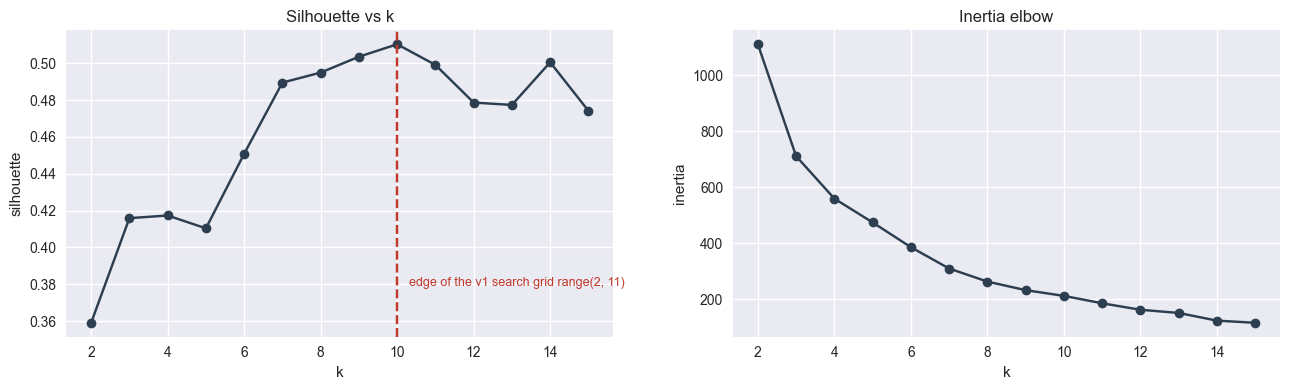

silhouette range over k=7..15: 0.474 to 0.510 (a spread of 0.036)
silhouette gain from k=2 to k=7 : +0.130
silhouette gain from k=7 to k=10: +0.021

The frozen notebook's own inertia-elbow cell concluded k=4-5; the selection cell used k=10.


In [21]:
K_RANGE = range(2, 16)
sil = {k: silhouette_score(X_pca4, KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_pca4))
       for k in K_RANGE}
inertia = {k: KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_pca4).inertia_ for k in K_RANGE}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(sil), list(sil.values()), marker="o", color="#2c3e50")
axes[0].axvline(10, color="#c0392b", ls="--")
axes[0].annotate("edge of the v1 search grid range(2, 11)", xy=(10, max(sil.values())),
                 xytext=(10.3, min(sil.values()) + 0.02), color="#c0392b", fontsize=9)
axes[0].set_xlabel("k"); axes[0].set_ylabel("silhouette"); axes[0].set_title("Silhouette vs k")
axes[1].plot(list(inertia), list(inertia.values()), marker="o", color="#2c3e50")
axes[1].set_xlabel("k"); axes[1].set_ylabel("inertia"); axes[1].set_title("Inertia elbow")
plt.tight_layout()
plt.show()

sil_s = pd.Series(sil)
print(f"silhouette range over k=7..15: {sil_s.loc[7:].min():.3f} to {sil_s.loc[7:].max():.3f} "
      f"(a spread of {sil_s.loc[7:].max() - sil_s.loc[7:].min():.3f})")
print(f"silhouette gain from k=2 to k=7 : {sil_s[7] - sil_s[2]:+.3f}")
print(f"silhouette gain from k=7 to k=10: {sil_s[10] - sil_s[7]:+.3f}")
print("\nThe frozen notebook's own inertia-elbow cell concluded k=4-5; the selection cell used k=10.")

In [22]:
km10 = KMeans(n_clusters=10, random_state=42, n_init=10).fit(X_pca4)
gmm10 = GaussianMixture(n_components=10, random_state=42).fit(X_pca4)

km_sizes = [int(v) for v in sorted(np.bincount(km10.labels_))[::-1]]
gmm_sizes = [int(v) for v in sorted(np.bincount(gmm10.predict(X_pca4)))[::-1]]

saved = pd.read_csv(VIRAJ_DIR / "data" / "merged_macro_credit_with_regimes.csv")
exported_sizes = [int(v) for v in sorted(saved["Regime_Label"].value_counts().to_numpy())[::-1]]

print(f"{'source':38s} cluster sizes (descending)")
print(f"{'KMeans k=10 (what cell 41 selected)':38s} {km_sizes}")
print(f"{'GMM k=10 (what cell 47 refit to)':38s} {gmm_sizes}")
print(f"{'labels actually exported to CSV':38s} {exported_sizes}")

n_params = 4 + 4 * 5 // 2 + 1
print(f"\nSmallest exported cluster: {min(exported_sizes)} observations.")
print(f"A 4-dimensional Gaussian component needs about {n_params} parameters "
      f"(mean, covariance, weight).")
print(f"BIC at k=10: {gmm10.bic(X_pca4):.2f}   "
      f"BIC at k=6: {GaussianMixture(n_components=6, random_state=42).fit(X_pca4).bic(X_pca4):.2f}")
print("Lower BIC is better, so k=10 is favoured by BIC even though it produces a 5-month cluster.")

source                                 cluster sizes (descending)
KMeans k=10 (what cell 41 selected)    [71, 56, 47, 36, 34, 29, 14, 13, 5, 4]
GMM k=10 (what cell 47 refit to)       [57, 50, 48, 34, 30, 27, 26, 19, 13, 5]
labels actually exported to CSV        [57, 48, 43, 34, 34, 30, 26, 19, 13, 5]

Smallest exported cluster: 5 observations.
A 4-dimensional Gaussian component needs about 15 parameters (mean, covariance, weight).
BIC at k=10: 2055.37   BIC at k=6: 2407.24
Lower BIC is better, so k=10 is favoured by BIC even though it produces a 5-month cluster.


The exported CSV carries ten `Regime_Prob_*` columns, described in v1 as soft probabilities that let
downstream models express uncertainty. Look at whether they actually vary.

In [23]:
prob_cols = [c for c in saved.columns if c.startswith("Regime_Prob_")]
probs = saved[prob_cols]
max_prob = probs.max(axis=1)

print(f"{len(prob_cols)} probability columns")
print(f"  rows where the top probability exceeds 0.999 : {(max_prob > 0.999).mean():.1%}")
print(f"  smallest top probability anywhere            : {max_prob.min():.6f}")
tiny = sorted({float(v) for v in probs.to_numpy().ravel() if v < 1e-3})[:4]
print(f"  distinct values below 0.001 include          : "
      f"{', '.join(f'{v:.3e}' for v in tiny)}")
print("\nFirst exported row, all ten probabilities:")
print(probs.iloc[0].to_string(float_format=lambda v: f"{v:.3e}"))
print("\nThese are a one-hot encoding of the hard label, not a distribution over regimes.")

10 probability columns
  rows where the top probability exceeds 0.999 : 87.7%
  smallest top probability anywhere            : 0.544364
  distinct values below 0.001 include          : 0.000e+00, 1.482e-323, 8.152e-322, 4.260e-318

First exported row, all ten probabilities:
Regime_Prob_0    5.221e-29
Regime_Prob_1   5.560e-314
Regime_Prob_2    2.833e-59
Regime_Prob_3    1.000e+00
Regime_Prob_4    0.000e+00
Regime_Prob_5   1.409e-195
Regime_Prob_6    0.000e+00
Regime_Prob_7    0.000e+00
Regime_Prob_8    0.000e+00
Regime_Prob_9    7.310e-52

These are a one-hot encoding of the hard label, not a distribution over regimes.


Finally the naming. v1 mapped cluster index 0-9 to ten names. Check whether that mapping was derived
from the centroids, or simply assigned in order.

In [24]:
name_cell = next(c for c in UNSUP["cells"]
                 if c["cell_type"] == "code" and "label_to_name" in cell_text(c))
mapping = dict(re.findall(r'(\d+):\s*"([^"]+)"', cell_text(name_cell)))
assigned = [mapping[str(i)] for i in range(len(mapping))]

print("v1 mapping, cluster index -> name:")
for i, nm in enumerate(assigned):
    print(f"  {i} -> {nm}")
print(f"\nIs that list in alphabetical order? {assigned == sorted(assigned)}")
print("No centroid-based ordering was applied; the names were attached in alphabetical sequence.")

v1 mapping, cluster index -> name:
  0 -> Boom Phase
  1 -> Crisis Peak
  2 -> Deep Recession
  3 -> Early Recovery
  4 -> Late-Cycle Surge
  5 -> Mid-Cycle Dip
  6 -> Mild Expansion
  7 -> Pre-Crisis Build-Up
  8 -> Slowdown
  9 -> Strong Expansion

Is that list in alphabetical order? True
No centroid-based ordering was applied; the names were attached in alphabetical sequence.


In [25]:
by_name = saved.groupby("Regime_Name").agg(
    n=("Credit_Spread", "size"),
    mean_spread=("Credit_Spread", "mean"),
    mean_EA19_GDP=("GDP", "mean"),
    mean_unemployment=("Unemployment_Rate", "mean"),
).sort_values("mean_spread")
display(by_name.round(3))

lowest = by_name.index[:3].tolist()
highest = by_name.index[-1]
crisis_like = [n for n in by_name.index if "Crisis" in n or "Recession" in n]
print(f"Regimes with the LOWEST mean spread: {lowest}")
print(f"Regime with the HIGHEST mean spread: {highest} "
      f"({by_name.loc[highest, 'mean_spread']:.3f})")
for nm in crisis_like:
    rank = list(by_name.index).index(nm) + 1
    print(f"  '{nm}' ranks {rank} of {len(by_name)} by mean spread "
          f"({by_name.loc[nm, 'mean_spread']:.3f})")

,n,mean_spread,mean_EA19_GDP,mean_unemployment
Regime_Name,,,,
Mid‐Cycle Dip,5,3.300,10.375,5.860
Early Recovery,34,3.811,1.905,3.885
Crisis Peak,13,3.834,4.385,3.992
Pre‐Crisis Build-Up,34,4.116,2.768,4.753
Mild Expansion,43,4.958,1.692,5.456
Strong Expansion,57,5.010,3.040,4.426
Slowdown,30,5.417,-1.864,7.547
Boom Phase,48,6.053,1.316,5.633
Late‐Cycle Surge,26,6.272,1.288,9.377


Regimes with the LOWEST mean spread: ['Mid‐Cycle Dip', 'Early Recovery', 'Crisis Peak']
Regime with the HIGHEST mean spread: Deep Recession (11.753)
  'Crisis Peak' ranks 3 of 10 by mean spread (3.834)
  'Pre‐Crisis Build-Up' ranks 4 of 10 by mean spread (4.116)
  'Deep Recession' ranks 10 of 10 by mean spread (11.753)


Two further problems with the regime layer, both checkable directly.

In [26]:
smooth_cell = next(c for c in UNSUP["cells"]
                   if c["cell_type"] == "code" and "Regime_Label_Smoothed" in cell_text(c)
                   and "rolling" in cell_text(c))
src_text = cell_text(smooth_cell)
print("The smoothing step, as written in the frozen notebook:")
print("  " + "\n  ".join(l for l in src_text.splitlines() if l.strip())[:400])
print(f"\n  uses center=True : {'center=True' in src_text}")
print("  A centred 3-month window at month t reads month t+1, so the smoothed label for any")
print("  month depends on the future. It was then used as a model feature.")

print("\nPC1 and the calendar:")
t = np.arange(len(RAW))
print(f"  correlation between PC1 and time index = {np.corrcoef(X_pca4[:, 0], t)[0, 1]:+.4f}")
loadings = pd.Series(pca4.components_[0], index=CLUSTER_COLS).sort_values()
print("  PC1 loadings:")
print(loadings.round(3).to_string())
print("\n  Because CPI, industrial production and the funds rate all trend over the sample, the")
print("  leading component is substantially a time trend, which is why the clusters read as eras.")

The smoothing step, as written in the frozen notebook:
  # Apply a 3-month rolling mode to remove single-month regime blips
  df_clean['Regime_Label_Smoothed'] = (
      df_clean['Regime_Label']
        .rolling(window=3, center=True)
        .apply(lambda x: x.mode()[0])
        .fillna(method='bfill')
        .fillna(method='ffill')
  )
  print(df_clean[['Regime_Label', 'Regime_Label_Smoothed']].head())

  uses center=True : True
  A centred 3-month window at month t reads month t+1, so the smoothed label for any
  month depends on the future. It was then used as a model feature.

PC1 and the calendar:
  correlation between PC1 and time index = -0.7386
  PC1 loadings:
CPI                     -0.438
Unemployment_Rate       -0.394
Industrial_Production   -0.235
GDP                      0.322
Consumer_Sentiment       0.471
FEDFUNDS                 0.521

  Because CPI, industrial production and the funds rate all trend over the sample, the
  leading component is substantially a time tre

---
## 8. Documentation versus code

Each row below pairs a numeric claim made in a markdown cell of a frozen notebook with the value
actually printed by a code cell in the same notebook. Both sides are extracted by regular expression
from the saved `.ipynb` JSON — neither is typed here.

In [27]:
p2_md, p2_out = all_markdown_text(P2), all_output_text(P2)
unsup_md = all_markdown_text(UNSUP)

CHECKS = [
    ("p2_models", "Phase 2 RF test MSE",
     find_number(p2_md, r"\*\*Test MSE = ([\d.]+)\*\*"),
     find_number(p2_out, r"\[RF\] Test\s+MSE=([\d.]+)")),
    ("p2_models", "Phase 2 RF test R2",
     find_number(p2_md, r"R² = ([\d.]+)\."),
     find_number(p2_out, r"\[RF\] Test.*?R²=(-?[\d.]+)")),
    ("p2_models", "Stacked-LSTM MSE",
     find_number(p2_md, r"\*Stacked-LSTM\* \(Iter-2, MSE ≈ ([\d.]+)\)"),
     find_number(p2_out, r"\[Stacked\] MSE=([\d.]+) MAE=3\.491")),
    ("p2_models", "GRU MSE",
     find_number(p2_md, r"\*GRU\* \(Iter-2, MSE ≈ ([\d.]+)\)"),
     find_number(p2_out, r"\[GRU-QuickWin\] Test MSE=([\d.]+)")),
    ("p2_models", "sequence feature count",
     find_number(p2_md, r"\*\*Feature count\*\* = (\d+)"),
     find_number(p2_out, r"Sequence feature count: (\d+)")),
    ("unsupervised", "GMM BIC at k=10",
     find_number(unsup_md, r"~(\d+) for k=10"),
     find_number(unsup_out, r"GaussianMixture\(n_components=10, random_state=42\)\s+([\d.]+)")),
    ("unsupervised", "'Deep Recession' duration (months)",
     find_number(unsup_md, r"“Deep Recession” \((\d+) months\)"),
     float(saved["Regime_Name"].value_counts().get("Deep Recession", np.nan))),
    ("unsupervised", "'Early Recovery' duration (months)",
     find_number(unsup_md, r"“Early Recovery” \((\d+) months\)"),
     float(saved["Regime_Name"].value_counts().get("Early Recovery", np.nan))),
]

doc_vs_code = pd.DataFrame(CHECKS, columns=["notebook", "quantity", "claimed in markdown",
                                            "actually printed / exported"])
doc_vs_code["agrees"] = np.isclose(doc_vs_code["claimed in markdown"],
                                   doc_vs_code["actually printed / exported"], rtol=0.02)
display(doc_vs_code)

n_bad = int((~doc_vs_code["agrees"]).sum())
print(f"{n_bad} of {len(doc_vs_code)} numeric claims disagree with the notebook's own output.")

,notebook,quantity,claimed in markdown,actually printed / exported,agrees
0,p2_models,Phase 2 RF test MSE,0.524,5.723000,False
1,p2_models,Phase 2 RF test R2,0.616,-3.194000,False
2,p2_models,Stacked-LSTM MSE,0.194,15.001000,False
3,p2_models,GRU MSE,0.171,6.748000,False
4,p2_models,sequence feature count,17.000,16.000000,False
5,unsupervised,GMM BIC at k=10,206.000,2061.868929,False
6,unsupervised,'Deep Recession' duration (months),70.000,19.000000,False
7,unsupervised,'Early Recovery' duration (months),56.000,34.000000,False


8 of 8 numeric claims disagree with the notebook's own output.


Three further contradictions are structural rather than numeric, so they are checked by inspecting
the source text directly.

In [28]:
sel_out = next(output_text(c) for c in UNSUP["cells"]
               if c["cell_type"] == "code" and "Selected:" in output_text(c))
claim_gmm = "GMM outperformed K-Means" in unsup_md
print("1. Which clustering method was selected")
print(f"   code printed      : {sel_out.strip().splitlines()[0]}")
print(f"   markdown asserts GMM outperformed K-Means: {claim_gmm}")

rf_cell_p2 = next(c for c in P2["cells"]
                  if c["cell_type"] == "code" and "feature_cols" in cell_text(c)
                  and "base_feats" in cell_text(c))
feat_line = next(l.strip() for l in cell_text(rf_cell_p2).splitlines()
                 if l.strip().startswith("feature_cols"))
claims_lags = "3 lags of `Credit_Spread`" in p2_md
print("\n2. Phase 2 RF feature set")
print(f"   code says         : {feat_line}")
print(f"   markdown claims three lags of Credit_Spread: {claims_lags}")

summary_cell = next(c for c in P2["cells"]
                    if c["cell_type"] == "code" and '"Model": ["RandomForest"' in cell_text(c))
literal_row = next(l.strip() for l in cell_text(summary_cell).splitlines() if '"MSE"' in l)
rf_printed_mse = find_number(p2_out, r"\[RF\] Test\s+MSE=([\d.]+)")
print("\n3. The final comparison table")
print(f"   code says         : {literal_row}")
print(f"   the RF value in that literal is typed, not read from the run that printed "
      f"MSE={rf_printed_mse:.3f}")

trace_cell = next((c for c in P2["cells"]
                   if c["cell_type"] == "markdown" and "Thought for" in cell_text(c)), None)
print("\n4. Provenance of the comparison prose")
print(f"   a markdown cell containing an assistant reasoning trace is present: {trace_cell is not None}")
if trace_cell is not None:
    snippet = " ".join(cell_text(trace_cell).split())[:180]
    print(f"   opening text: \"{snippet}...\"")

1. Which clustering method was selected
   code printed      : Selected: kmeans (k=10) | silhouette=0.515, CH=247.2
   markdown asserts GMM outperformed K-Means: True

2. Phase 2 RF feature set
   code says         : feature_cols = base_feats + cat_col
   markdown claims three lags of Credit_Spread: True

3. The final comparison table
   code says         : "MSE":  [0.524, mse1,     mse2_final, mse3,     mse4],
   the RF value in that literal is typed, not read from the run that printed MSE=5.723

4. Provenance of the comparison prose
   a markdown cell containing an assistant reasoning trace is present: True
   opening text: "**Clarifying model performance metrics** I’m thinking through how to present the comparisons for model performance metrics like MSE, MAE, and R². It seems like I don’t have exact m..."


**Read the result.** The disagreements are not rounding. Two of the deep-learning figures quoted in
the Phase 2 conclusions are smaller than the printed values by roughly two orders of magnitude, and
the sign of the R² is reversed. The final comparison table contains a typed constant where a
computed variable belongs. One markdown cell still contains the assistant reasoning trace that
produced the surrounding prose.

The regime-duration rows have a specific mechanical explanation worth recording: the durations
quoted in the markdown match the **KMeans** solution, while the labels actually exported to CSV came
from the **GMM** that a later cell silently refit and assigned over `best_model`. The prose was
describing a different model than the one whose output was saved.

---
## 9. What this means, and what v2 changes

**The headline result is not a forecast.** The Phase 1 feature matrix contains an exact linear
reconstruction of its own label, and the label is the current month rather than the next one. The
reported figure cannot be reproduced from the frozen notebook's saved evidence either, because those
outputs span more than one kernel session. Both the number and the interpretation have to go.

**The claims in `notes/` that rest on that result do not survive.** Any statement that macro
variables explain most of the out-of-sample variation in high-yield spreads traces back to this
model. What the data supports instead is narrower and duller: spreads are extremely persistent, and
last month's spread is a strong predictor of this month's.

**"Deep learning underperformed because the sample is small" is unproven.** The sequence models were
handed a feature set with no spread history at all, while the random forest they were compared
against had it, on a target as persistent as section 5 measures. Ten of their sixteen inputs were
a degenerate one-hot of the regime label. That comparison cannot support a conclusion about model
families; it only shows that removing the dominant predictor hurts.

**The regime layer describes calendar eras, not economic states.** It was fitted on the full sample
including the test period, smoothed with a window that reads one month into the future, given a
cluster count chosen at the edge of its own search grid and against its own elbow diagnostic, and
named in alphabetical order. The regime with "Crisis" in its name has one of the *lowest* mean
spreads in the sample.

**The `GDP` column is not US GDP.** It is the OECD Leading Indicators reference series for Euro Area
19 GDP, year on year, interpolated monthly from quarterly data — and it is the highest-loading
variable in the regime clustering. It is mislabelled in the data, the code, `README.md` and most of
`notes/`.

**What v2 does differently**

| Finding | v2 response | Where |
|---|---|---|
| Rolling windows include row `t` | Windows shifted; the shift is in the column name | `src/features.py` |
| Target recoverable from features | `leakage_report` run as a test, not an eyeball check | `tests/test_features.py` |
| Fitted the current month | Explicit `y_Credit_Spread_h1` target, name returned to the caller | `src/features.py` |
| No naive baseline anywhere | Random walk, AR(1) and train-mean fitted before any model | `03_baselines_first.ipynb` |
| Single split, no error bar | Expanding walk-forward with purge and embargo | `src/splits.py`, `05_...` |
| Regimes fitted on the full sample | PCA and clustering refit inside each fold; no centred smoothing | `04_regimes_real_time.ipynb` |
| No publication lags | Per-series `release_lag_months` applied | `src/config_v2.py`, `01_...` |
| `GDP` mislabelled | Renamed `EA19_GDP_YoY_OECD`, provenance recorded | `src/config_v2.py` |
| Typed metrics in result tables | One writer for `results/metrics.csv`; notebooks interpolate | `src/evaluate.py` |
| Non-stationarity never tested | ADF and KPSS run before any level regression | `02_...` |

The frozen notebooks stay exactly as they are. They are the record of what was originally reported,
and this notebook is the runnable demonstration of what was wrong with it.